# CS 198/199 
# Joaquin B. Salvador
# Explainable AI for Post-COVID Psychological Profile Prediction

## 2.1
### RandomForest

# Data Preparation

We currently have a dataset from an online survey conducted on the Japanese population when the number of COVID-19-positive cases was high and when the COVID-19 pandemic was officially declared to be over. The dataset has 92 attributes, including socio-demographic, COVID-19-related, mental health, and coping behavior information from 2,659 respondents.

In [1]:
# -------------------------------------
# Library configuration
# -------------------------------------
# Standard libraries
import numpy as np
import pandas as pd

# ML libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# XAI libraries
import shap

In [2]:
# -------------------------------------
# Settings
# -------------------------------------
random_state = 42

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


## Data preprocessing

In [3]:
# Loading dataset
df = pd.read_csv('../data/data.csv')

In [4]:
# Displaying dataset
df

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,1106,2022/05/13-19:39:52,1.0,67.0,14.0,2.0,2.0,3.0,1.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,2022/05/14-08:44:24,1.0,57.0,40.0,2.0,2.0,5.0,3.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,2022/05/13-20:19:11,1.0,62.0,11.0,2.0,2.0,2.0,2.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,2022/05/14-18:23:23,1.0,55.0,40.0,2.0,2.0,4.0,3.0,4.0,...,0.0,12.0,15.0,14.0,18.0,19.0,4.0,24.0,4.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24045,30063086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24046,30081779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24047,30093317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24048,30094439,2022/05/13-21:35:19,2.0,34.0,28.0,2.0,1.0,10.0,1.0,8.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Sorting dataset based on SAMPLEID
df_sorted = df.sort_values(by=['SAMPLEID'])

In [6]:
# Displaying sorted dataset
df_sorted

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
0,1106,2022/05/13-19:39:52,1.0,67.0,14.0,2.0,2.0,3.0,1.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16161,1171,2022/05/13-19:35:52,1.0,59.0,14.0,2.0,2.0,6.0,5.0,3.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16162,1263,2022/05/13-19:44:02,1.0,73.0,14.0,2.0,2.0,2.0,2.0,12.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14191,1346,2022/05/13-19:00:17,1.0,52.0,26.0,2.0,2.0,3.0,3.0,2.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18612,1398,2022/05/13-20:26:45,1.0,52.0,27.0,1.0,1.0,3.0,3.0,6.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17614,30094793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16160,30094932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24049,30095042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20047,30095074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Dropping empty rows from sorted dataset
df_cleaned = df_sorted.dropna()

In [8]:
# Displaying cleaned dataset
df_cleaned

,SAMPLEID,ANSWERDATE,5_SEX,5_AGE,5_PREFECTURE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,...,5_AUDIT_group,6_K6_total,6_PHQ9_total,6_GAD7_total,6_SSS8_total,6_PTGI-X(Q7_22_27),6_SHS_total,6_UCLA_total,6_LSNS6_total,6_AUDIT
4,3793,2022/05/14-18:23:23,1.0,55.0,40.0,2.0,2.0,4.0,3.0,4.0,...,0.0,12.0,15.0,14.0,18.0,19.0,4.00,24.0,4.0,6.0
8,9703,2022/05/14-07:51:04,2.0,68.0,28.0,2.0,2.0,8.0,1.0,8.0,...,0.0,1.0,0.0,0.0,1.0,3.0,4.50,11.0,18.0,0.0
11,11532,2022/05/14-12:53:15,1.0,50.0,13.0,1.0,1.0,3.0,3.0,3.0,...,0.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0,0.0,0.0
15,15778,2022/05/13-19:09:38,1.0,64.0,27.0,2.0,2.0,5.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,18.0,5.50,21.0,13.0,0.0
19,18713,2022/05/13-22:01:06,1.0,61.0,13.0,2.0,2.0,10.0,10.0,2.0,...,0.0,0.0,2.0,0.0,0.0,15.0,5.25,22.0,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11204,26475923,2022/05/15-01:24:36,1.0,55.0,27.0,1.0,2.0,2.0,2.0,3.0,...,0.0,12.0,4.0,7.0,13.0,18.0,4.00,25.0,6.0,6.0
11208,26476814,2022/05/13-19:35:37,1.0,53.0,13.0,2.0,2.0,7.0,7.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.00,25.0,0.0,0.0
11209,26476898,2022/05/13-21:36:28,2.0,48.0,40.0,2.0,1.0,5.0,1.0,8.0,...,0.0,13.0,6.0,0.0,5.0,12.0,3.75,26.0,4.0,0.0
11288,26520090,2022/05/13-19:39:54,2.0,31.0,13.0,1.0,1.0,3.0,3.0,3.0,...,0.0,2.0,3.0,2.0,14.0,12.0,4.00,27.0,3.0,0.0


In [9]:
# Gathering column names
column_names = df_cleaned.columns.tolist()

In [10]:
# Displaying column names
column_names

['SAMPLEID',
 'ANSWERDATE',
 '5_SEX',
 '5_AGE',
 '5_PREFECTURE',
 '5_MARRIED',
 '5_CHILD',
 '5_HINCOME',
 '5_PINCOME',
 '5_JOB',
 '5_STUDENT',
 '5_Number_fam',
 '5_SchoolGrade',
 '5_YearsEnrolled',
 '5_VacNum',
 '5_UkraineMoviePicture',
 '5_UkraineReadListen',
 '5_Med_self',
 '5_Medself_covid',
 '5_Med_fam',
 '5_Medfam_covid',
 '5_Current_physical',
 '5_Past_physical',
 '5_Current_mental',
 '5_Past_mental',
 '5_Current_covid19',
 '5_Past_covid19',
 '5_K6_total',
 '5_PHQ9_total',
 '5_GAD7_total',
 '5_SSS8_total',
 '5_PTGI-X(Q7_39_44)',
 '5_MAIA_1',
 '5_MAIA_2',
 '5_MAIA_3',
 '5_MAIA_4',
 '5_MAIA_5',
 '5_MAIA_6',
 '5_MAIA_7',
 '5_MAIA_8',
 '5_SHS_total',
 '5_UCLA_total',
 '5_LSNS6_total',
 '5_AUDIT',
 '5_Exercise',
 '5_HealthyDiet',
 '5_FavoriteActivity',
 '5_Interaction_offline',
 '5_Interaction_online',
 '5_PB_Continuous',
 '5_PB_Altruistic',
 '5_PB_Avoidant',
 '5_Trust_gov',
 '5_Trust_SM',
 '5_Vaccination_will',
 '5_PB_understanding',
 '5_Optimism',
 '5_HealthySleep',
 '5_Deterioratio

In [11]:
# Setting targets
#df_targets = df_cleaned[['6_K6_total',
# '6_PHQ9_total',
# '6_GAD7_total',
# '6_SSS8_total',
# '6_PTGI-X(Q7_22_27)',
# '6_SHS_total',
# '6_UCLA_total',
# '6_LSNS6_total',
# '6_AUDIT']]

df_target = df_cleaned[['6_K6_total']]

#num_targets = len(df_targets.columns.tolist())

In [12]:
# Setting features
df_features = df_cleaned.drop([
 'SAMPLEID',
 'ANSWERDATE',
'5_PREFECTURE',
 '6_K6_total',
 '6_PHQ9_total',
 '6_GAD7_total',
 '6_SSS8_total',
 '6_PTGI-X(Q7_22_27)',
 '6_SHS_total',
 '6_UCLA_total',
 '6_LSNS6_total',
 '6_AUDIT'], axis=1)

num_features = len(df_features.columns.tolist())

# Building the model


In [13]:
from sklearn import preprocessing
import numpy as np
X = df_features
y = df_target

In [14]:
# split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = random_state)

In [15]:
X_train

,5_SEX,5_AGE,5_MARRIED,5_CHILD,5_HINCOME,5_PINCOME,5_JOB,5_STUDENT,5_Number_fam,5_SchoolGrade,...,5_Mental_group,5_Covid_group,5_K6_group3,5_K6_group2,5_PHQ9_%,5_GAD_%,5_PHQ9_item9,5_PHQ9_SI,5_LSNS_group,5_AUDIT_group
8759,2.0,37.0,1.0,1.0,1.0,1.0,12.0,0.0,2.0,0.0,...,4.0,3.0,1.0,1.0,1.0,0.0,2.0,1.0,1.0,0.0
8576,2.0,76.0,2.0,2.0,2.0,1.0,8.0,0.0,1.0,0.0,...,3.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
6406,1.0,74.0,2.0,2.0,1.0,1.0,12.0,0.0,2.0,0.0,...,4.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
5327,2.0,42.0,2.0,1.0,3.0,2.0,3.0,0.0,1.0,0.0,...,3.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8833,1.0,67.0,2.0,2.0,4.0,4.0,5.0,0.0,1.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5009,2.0,59.0,1.0,1.0,10.0,1.0,12.0,0.0,2.0,0.0,...,3.0,4.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
3161,1.0,73.0,2.0,2.0,2.0,2.0,12.0,0.0,1.0,0.0,...,4.0,4.0,3.0,2.0,1.0,0.0,2.0,1.0,1.0,0.0
3265,1.0,77.0,2.0,2.0,3.0,3.0,12.0,0.0,2.0,0.0,...,4.0,4.0,2.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0
3781,2.0,26.0,1.0,1.0,10.0,3.0,4.0,0.0,6.0,0.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [16]:
y_train

,6_K6_total
8759,15.0
8576,6.0
6406,5.0
5327,0.0
8833,1.0
...,...
5009,3.0
3161,15.0
3265,6.0
3781,0.0


In [17]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=random_state)
rfc.fit(X_train, y_train)

E:\py3-10\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

In [18]:
y_pred = rfc.predict(X_test)

In [19]:
# Check accuracy score 

from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.4704


In [41]:
# instantiate the classifier with n_estimators = 100

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

rfc_100.fit(X_train, y_train)



# Predict on the test set results

y_pred_100 = rfc_100.predict(X_test)



# Check accuracy score 

print('Model accuracy score with 100 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_100)))

/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model accuracy score with 100 decision-trees : 0.4704


In [42]:


# create the classifier with n_estimators = 100

clf = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

clf.fit(X_train, y_train)



/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=0)

In [43]:


# view the feature scores

feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores



5_K6_total         0.049472
5_PHQ9_total       0.041605
5_GAD7_total       0.032848
5_SSS8_total       0.030511
5_AGE              0.026396
                     ...   
5_SchoolGrade      0.000072
5_STUDENT          0.000063
5_YearsEnrolled    0.000012
5_LSNS_group       0.000000
5_AUDIT_group      0.000000
Length: 87, dtype: float64

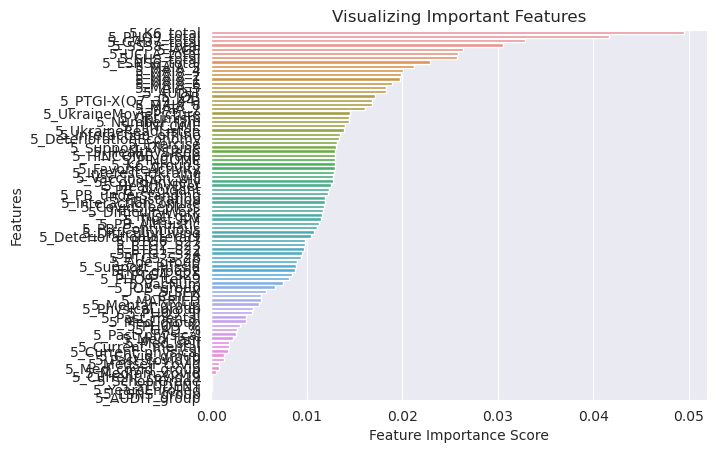

In [44]:


# Creating a seaborn bar plot

sns.barplot(x=feature_scores, y=feature_scores.index)



# Add labels to the graph

plt.xlabel('Feature Importance Score')

plt.ylabel('Features')



# Add title to the graph

plt.title("Visualizing Important Features")



# Visualize the graph

plt.show()



In [45]:


# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)



Confusion matrix

 [[398   2   0   2   1   0   3   1   0   0   0   0   7   0   0   1   0   0
    0   0   1   0   0   0   0]
 [ 79   1   1   1   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 48   0   0   0   0   1   2   1   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 37   0   1   1   0   1   2   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 25   4   0   0   0   1   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 25   1   0   1   0   2   6   0   0   0   1   0   3   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 17   3   0   0   1   0   3   1   1   0   1   0   4   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 16   0   0   1   0   3   6   0   0   0   0   0   3   0   0   0   0   0
    0   0   0   0   0   0   0]
 [ 10   0   0   0   0   1   5   1   0   0   1   0   0   0   0   0   0   0
    0   1   0   0   0   0   0]
 [  6   0   2   0   0   1   2   2   

In [46]:


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

         0.0       0.57      0.96      0.72       416
         1.0       0.06      0.01      0.02        85
         2.0       0.00      0.00      0.00        53
         3.0       0.11      0.02      0.04        42
         4.0       0.00      0.00      0.00        31
         5.0       0.11      0.05      0.07        39
         6.0       0.06      0.10      0.08        31
         7.0       0.00      0.00      0.00        29
         8.0       0.00      0.00      0.00        19
         9.0       0.00      0.00      0.00        14
        10.0       0.00      0.00      0.00        20
        11.0       0.00      0.00      0.00        15
        12.0       0.12      0.25      0.16        16
        13.0       0.00      0.00      0.00        15
        14.0       0.00      0.00      0.00         7
        15.0       0.00      0.00      0.00         7
        16.0       0.00      0.00      0.00         2
        17.0       0.00    

/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=20, random_state=42, class_weight="balanced")


In [48]:
rf_clf.fit(X_train, y_train)


/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=150,
                       random_state=42)

In [49]:
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.46
Classification Report:
               precision    recall  f1-score   support

         0.0       0.54      0.97      0.70       416
         1.0       0.00      0.00      0.00        85
         2.0       0.00      0.00      0.00        53
         3.0       0.00      0.00      0.00        42
         4.0       0.00      0.00      0.00        31
         5.0       0.00      0.00      0.00        39
         6.0       0.04      0.03      0.04        31
         7.0       0.00      0.00      0.00        29
         8.0       0.25      0.05      0.09        19
         9.0       0.00      0.00      0.00        14
        10.0       0.00      0.00      0.00        20
        11.0       0.00      0.00      0.00        15
        12.0       0.00      0.00      0.00        16
        13.0       0.00      0.00      0.00        15
        14.0       0.00      0.00      0.00         7
        15.0       0.00      0.00      0.00         7
        16.0       0.00      0.00      0.0

/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(estimator=rf_clf, param_distributions=param_dist, n_iter=50, cv=3, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

best_model = rf_random.best_estimator_
print(f"Best parameters: {rf_random.best_params_}")


/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return f

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}


In [51]:
rf_optimized = RandomForestClassifier(n_estimators=300, min_samples_split=5, min_samples_leaf=1, max_depth=None, bootstrap=True, random_state=42, class_weight="balanced")

In [53]:
rf_optimized.fit(X_train, y_train)


/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       n_estimators=300, random_state=42)

In [54]:
y_pred = rf_optimized.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.47
Classification Report:
               precision    recall  f1-score   support

         0.0       0.62      0.93      0.74       416
         1.0       0.00      0.00      0.00        85
         2.0       0.00      0.00      0.00        53
         3.0       0.09      0.02      0.04        42
         4.0       0.00      0.00      0.00        31
         5.0       0.14      0.10      0.12        39
         6.0       0.09      0.13      0.11        31
         7.0       0.00      0.00      0.00        29
         8.0       0.29      0.11      0.15        19
         9.0       0.00      0.00      0.00        14
        10.0       0.00      0.00      0.00        20
        11.0       0.07      0.07      0.07        15
        12.0       0.10      0.25      0.14        16
        13.0       0.00      0.00      0.00        15
        14.0       0.00      0.00      0.00         7
        15.0       0.00      0.00      0.00         7
        16.0       0.00      0.00      0.0

/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joaquin/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:


import shap 



In [57]:


# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(rf_optimized)



In [61]:
shap_values = explainer.shap_values(X_train)

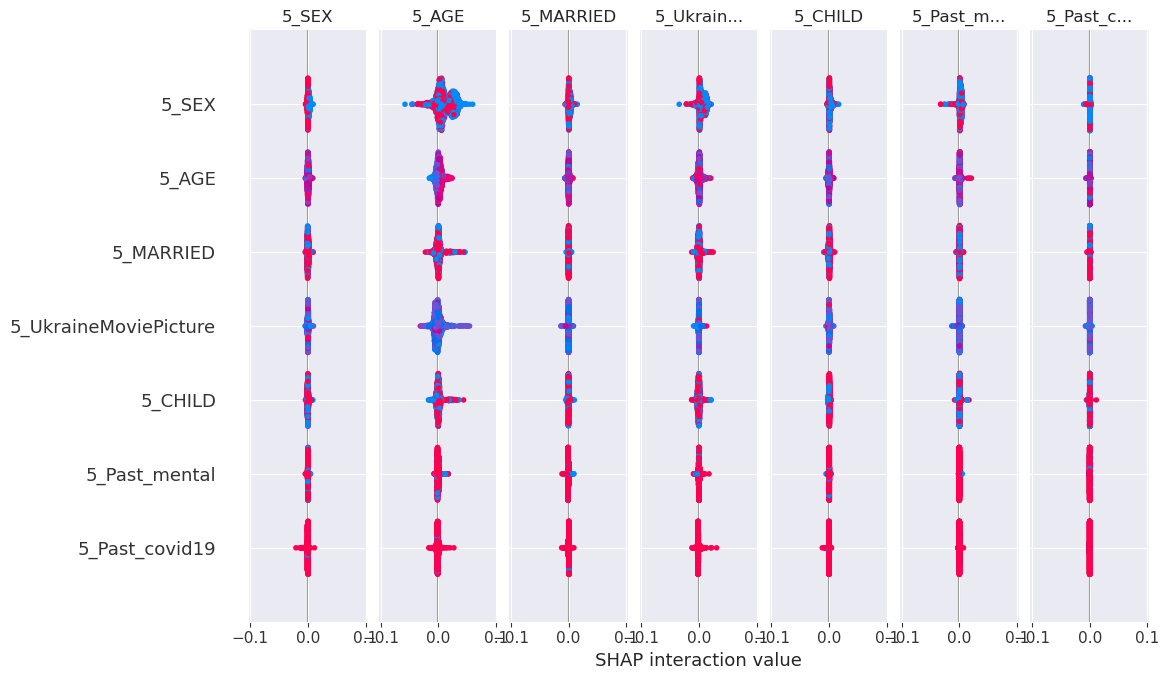

In [62]:
shap.summary_plot(shap_values, X_train)

https://www.kaggle.com/code/prashant111/random-forest-classifier-tutorial

https://www.kaggle.com/code/vikumsw/explaining-random-forest-model-with-shapely-values

